In [1]:
cleaned_data_path = "cleaned_data"
raw_data_model_path = "raw_data"

In [2]:
import os
import pandas as pd

for year in range(2019, 2021):
    if not os.path.exists(f"{raw_data_model_path}/LLCP{year}.XPT"):
        print(f"File LLCP{year}.XPT does not exist in {raw_data_model_path}.")
        continue

    df = pd.read_sas(f"{raw_data_model_path}/LLCP{year}.XPT", format="xport")
    print(df.columns)
    df.to_csv(f"{cleaned_data_path}/LLCP{year}.csv", index=False)



File LLCP2019.XPT does not exist in raw_data.
File LLCP2020.XPT does not exist in raw_data.


In [3]:
import os
import pandas as pd

# 추출할 컬럼 정의
selected_columns = [
    'MENTHLTH', '_MENT14D', 'DEPRSSN', 'POORHLTH',   # 정신건강 관련
    '_AGE_G', 'SEX', 'INCOME2', 'EDUCA', 'RACEGR3'      # 인구통계 관련
]

summary = []

for year in range(2019, 2024):
    input_path = f"{cleaned_data_path}/LLCP{year}.csv"
    output_path = f"{cleaned_data_path}/LLCP{year}_mental_subset.csv"

    if not os.path.exists(input_path):
        print(f"File LLCP{year}.csv does not exist in cleaned_data_path.")
        continue

    # 기존 CSV 불러오기
    df = pd.read_csv(input_path, low_memory=False)

    # 존재하는 컬럼만 추출
    available_cols = [col for col in selected_columns if col in df.columns]
    filtered_df = df[available_cols].copy()

    # 저장
    filtered_df.to_csv(output_path, index=False)
    print(f"[{year}] Extracted {len(filtered_df)} rows with {len(available_cols)} columns → {output_path}")

    # 요약용 로그
    summary.append({"year": year, "columns": available_cols, "records": len(filtered_df)})

# 전체 요약 출력
summary_df = pd.DataFrame(summary)
print(summary_df)


File LLCP2019.csv does not exist in cleaned_data_path.
File LLCP2020.csv does not exist in cleaned_data_path.
File LLCP2021.csv does not exist in cleaned_data_path.
File LLCP2022.csv does not exist in cleaned_data_path.
File LLCP2023.csv does not exist in cleaned_data_path.
Empty DataFrame
Columns: []
Index: []


In [35]:
from collections import defaultdict

age_map = {
    1: '18–24',
    2: '25–34',
    3: '35–44',
    4: '45–54',
    5: '55–64',
    6: '65+'
}

final_summary = []

for year in range(2019, 2024):
    input_path = f"{cleaned_data_path}/LLCP{year}_mental_subset.csv"
    if not os.path.exists(input_path):
        continue

    df = pd.read_csv(input_path, low_memory=False)

    if '_AGE_G' not in df.columns or '_MENT14D' not in df.columns:
        continue

    df['_AGE_G'] = pd.to_numeric(df['_AGE_G'], errors='coerce')
    df['_MENT14D'] = pd.to_numeric(df['_MENT14D'], errors='coerce')

    total = len(df)
    mentally_unwell_df = df[df['_MENT14D'] == 1]
    total_unwell = len(mentally_unwell_df)
    overall_ratio = round(total_unwell / total * 100, 2)

    # 나이 그룹별 mentally unwell 비율 계산 (분자: age group within mentally unwell)
    age_unwell_counts = mentally_unwell_df['_AGE_G'].value_counts().to_dict()
    age_group_breakdown = []

    for code, label in age_map.items():
        if code == 5 or code == 6:
            continue
        count = age_unwell_counts.get(code, 0)
        percent_within_unwell = round(count / total_unwell * 100, 2) if total_unwell else 0
        age_group_breakdown.append({
            "age_group": label,
            "unwell_count": count,
            "percent_within_unwell": percent_within_unwell
        })

    final_summary.append({
        "year": year,
        "total_respondents": total,
        "total_mentally_unwell": total_unwell,
        "mentally_unwell_ratio (%)": overall_ratio,
        "age_group_breakdown": age_group_breakdown
    })

for row in final_summary:
    print(f"\n📅 Year: {row['year']}")
    print(f"Total Respondents: {row['total_respondents']}")
    print(f"Mentally Unwell (14+ days): {row['total_mentally_unwell']} "
          f"({row['mentally_unwell_ratio (%)']}%)")

    print("Breakdown of Mentally Unwell by Age Group:")
    for group in row['age_group_breakdown']:
        print(f"  - {group['age_group']}: {group['unwell_count']} "
              f"({group['percent_within_unwell']}%)")



📅 Year: 2019
Total Respondents: 418268
Mentally Unwell (14+ days): 267337 (63.92%)
Breakdown of Mentally Unwell by Age Group:
  - 18–24: 10341 (3.87%)
  - 25–34: 21640 (8.09%)
  - 35–44: 27588 (10.32%)
  - 45–54: 36680 (13.72%)

📅 Year: 2020
Total Respondents: 401958
Mentally Unwell (14+ days): 255707 (63.62%)
Breakdown of Mentally Unwell by Age Group:
  - 18–24: 11122 (4.35%)
  - 25–34: 22087 (8.64%)
  - 35–44: 29029 (11.35%)
  - 45–54: 37762 (14.77%)

📅 Year: 2021
Total Respondents: 438693
Mentally Unwell (14+ days): 271161 (61.81%)
Breakdown of Mentally Unwell by Age Group:
  - 18–24: 9978 (3.68%)
  - 25–34: 21525 (7.94%)
  - 35–44: 31190 (11.5%)
  - 45–54: 39988 (14.75%)

📅 Year: 2022
Total Respondents: 445132
Mentally Unwell (14+ days): 265229 (59.58%)
Breakdown of Mentally Unwell by Age Group:
  - 18–24: 9388 (3.54%)
  - 25–34: 19793 (7.46%)
  - 35–44: 29281 (11.04%)
  - 45–54: 37676 (14.21%)

📅 Year: 2023
Total Respondents: 433323
Mentally Unwell (14+ days): 257026 (59.32%)
Bre

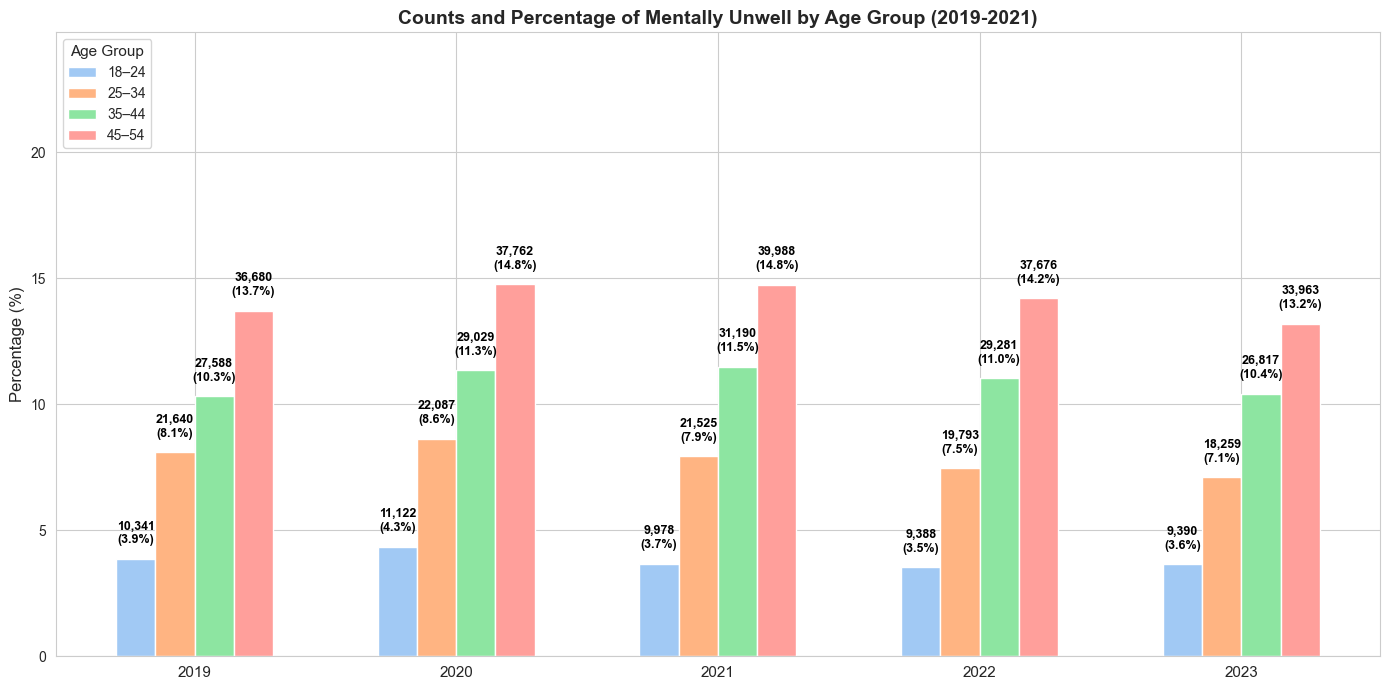

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Seaborn 스타일
sns.set_style("whitegrid")
sns.set_palette("pastel")

years = [s["year"] for s in final_summary]
age_groups = [g["age_group"] for g in final_summary[0]["age_group_breakdown"]]
n_age = len(age_groups)

bar_width = 0.15
x = np.arange(len(years))

plt.figure(figsize=(14, 7))

for i, group in enumerate(age_groups):
    counts = [summary["age_group_breakdown"][i]["unwell_count"] for summary in final_summary]
    percents = [summary["age_group_breakdown"][i]["percent_within_unwell"] for summary in final_summary]
    
    offsets = x + (i - n_age / 2) * bar_width + bar_width / 2
    bars = plt.bar(offsets, percents, width=bar_width, label=group)
    
    for xi, cnt, pct in zip(offsets, counts, percents):
        plt.text(
            xi, pct + 0.5,
            f"{cnt:,}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color="black"
        )

plt.xticks(x, years, fontsize=11)
plt.ylabel("Percentage (%)", fontsize=12)
plt.title("Counts and Percentage of Mentally Unwell by Age Group (2019-2021)", fontsize=14, weight='bold')
plt.ylim(0, max(max([g["percent_within_unwell"] for g in s["age_group_breakdown"]]) for s in final_summary) + 10)

plt.legend(title="Age Group", fontsize=10, title_fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()
